# Keyframe Extraction

Select representative frames from raw video before running structure-from-motion. This notebook compares two strategies — fixed-rate (FPS) and optical-flow-driven — and shows how the choice affects spatial coverage of the resulting point cloud.

**Prerequisites:** a video file at `VIDEO_PATH` below; no GPU required for frame scoring.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import json
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt

from collab_splats.preproc import (
    extract_frames,
    get_video_info,
    load_frames,
    sample_frames,
    score_frames,
)
from collab_splats.preproc.viz import (
    plot_disparity_sensitivity,
    plot_frame_grid,
    plot_frame_scores,
    plot_quality_examples,
    plot_selection,
)

In [3]:
%run ../tutorial_config.py

# ── Configuration ─────────────────────────────────────────────────────────────
# All notebook output goes under TUTORIAL_CACHE — the canonical scene dir
# (OUTPUT_DIR, incl. FRAMES) is pipeline-owned and read-only here.
FRAME_SCORES = TUTORIAL_CACHE / "frame_scores.json"
KEYFRAMES = TUTORIAL_CACHE / "keyframes"

## §0 — Why Frame Selection Matters

COLMAP (the structure-from-motion tool underlying most 3D reconstruction pipelines) builds a point cloud by finding matching features across frames. **The frames you give it determine the shape, density, and coverage of the result.**

Two failure modes:
- **Over-sampling slow regions:** A slow camera pan generates dozens of nearly identical frames. COLMAP spends budget on redundant matches; the resulting point cloud is dense in that region and sparse elsewhere.
- **Under-sampling fast transitions:** If the camera moves quickly through a room and you sample at fixed rate, interesting transitions may get fewer frames than a stationary shot.

**Even (FPS) sampling** extracts frames at a fixed temporal rate — uniform in time but biased toward regions filmed slowly.

**Optical flow (OF) sampling** extracts frames only when the scene content changes significantly — uniform in content, regardless of filming speed.

## §1 — Load Video

Set paths, create cache directories, and inspect video metadata. All subsequent cells read from `VIDEO_PATH` and write outputs under `TUTORIAL_CACHE`.

In [4]:
# Tutorial scratch dir; the canonical scene dir is never written to
TUTORIAL_CACHE.mkdir(parents=True, exist_ok=True)

# Load video metadata
info = get_video_info(VIDEO_PATH)
print(f"Video: {VIDEO_PATH}")
print(f"Scratch: {TUTORIAL_CACHE.resolve()}")
print(f"Frames: {info['total_frames']}  FPS: {info['fps']:.1f}  Duration: {info['duration_s']:.1f}s")

Video: /workspace/outputs/2024_02_06/C0043/C0043.MP4
Scratch: /workspace/outputs/tutorial_cache/2024_02_06/C0043
Frames: 2388  FPS: 24.0  Duration: 99.6s


Preview one frame per second to get a sense of scene content and camera motion before selecting keyframes.

Uniform sampling:   0%|          | 0/2388 [00:00<?, ?frame/s]

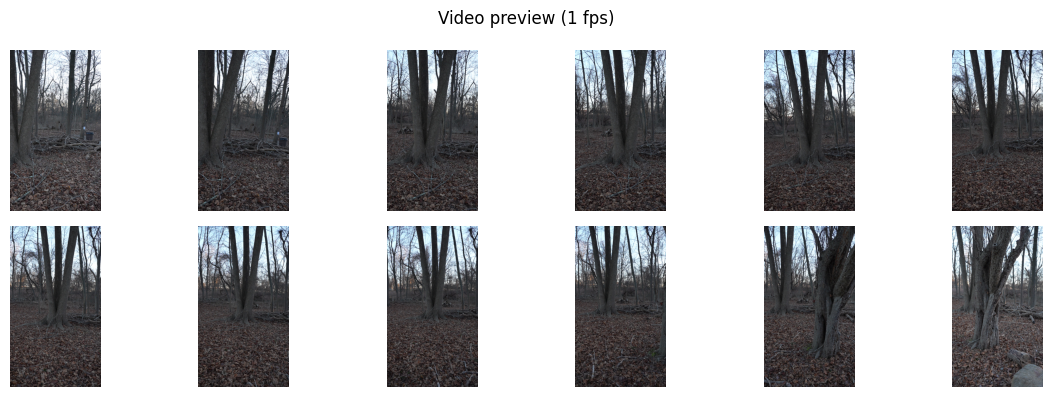

In [5]:
# Preview: 1 frame per second to survey scene content
preview_frames, _ = sample_frames(VIDEO_PATH, method="uniform", fps=1.0, max_frames=12)
plot_frame_grid(preview_frames, title="Video preview (1 fps)")

## §2 — Even Sampling (FPS)

Extract frames at a fixed temporal rate. The result is uniformly spaced in time but biased toward regions filmed slowly — slow pans generate many redundant frames while fast transitions get few.

Uniform sampling:   0%|          | 0/2388 [00:00<?, ?frame/s]

Uniform sampling selected 199 frames


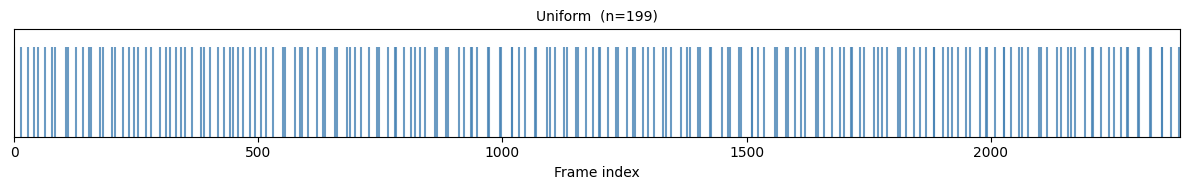

In [6]:
TARGET_FPS = 2.0  # adjust to taste
fps_frames, fps_records = sample_frames(VIDEO_PATH, method="uniform", fps=TARGET_FPS)
fps_indices = [r["frame_idx"] for r in fps_records]

print(f"Uniform sampling selected {len(fps_frames)} frames")
plot_selection(info['total_frames'], fps_indices=fps_indices)

The timeline above shows *when* frames were selected. The grid below shows *what* those frames look like — useful for spotting redundant or blurry picks.

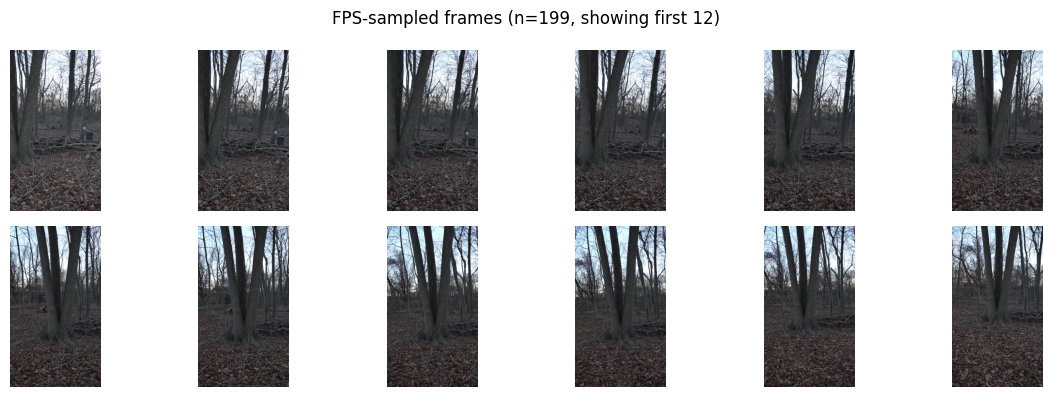

In [7]:
plot_frame_grid(fps_frames[:12], title=f"FPS-sampled frames (n={len(fps_frames)}, showing first 12)")

## §3 — Optical Flow Score Timeseries

Score every frame using optical flow before selecting keyframes. `score_frames` also applies the quality gate — blurred or badly exposed frames are marked unselectable. Three signals drive selection:
- **Disparity:** mean pixel displacement of tracked feature points — how much the camera moved
- **Rotation:** estimated camera rotation between frames
- **Histogram similarity:** how similar the current frame looks to the last accepted keyframe

Spikes indicate camera motion or scene change; flat regions indicate redundant frames.

Loaded frame scores from cache (2388 frames)


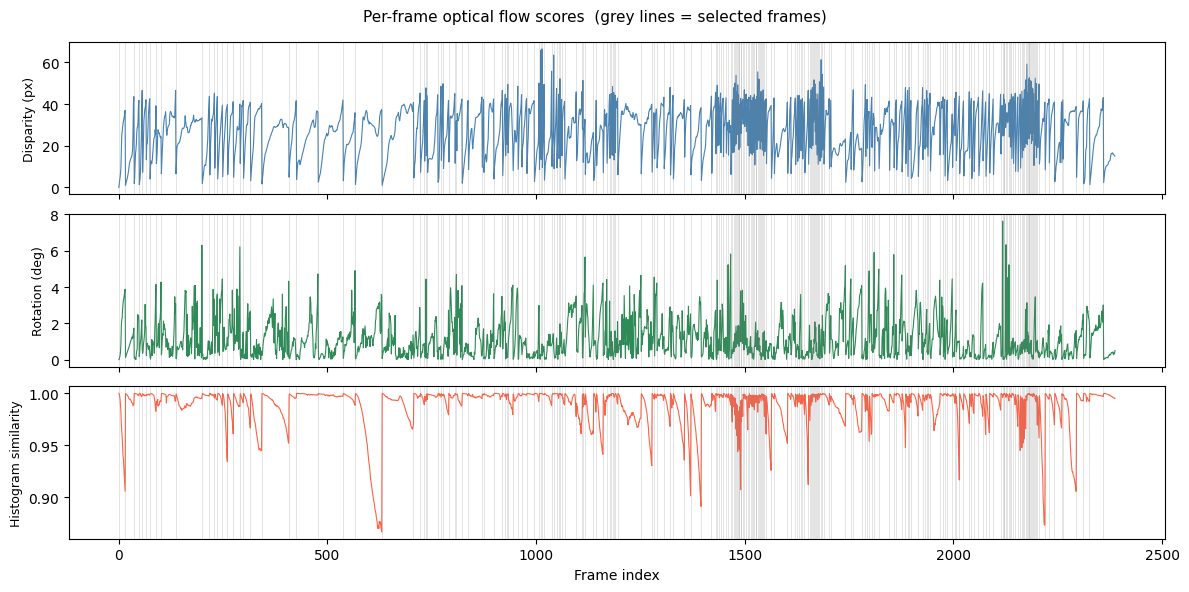

In [8]:
frame_scores = None
if FRAME_SCORES.exists():
    cached = json.loads(FRAME_SCORES.read_text())
    # Invalidate caches written before reject_reason existed
    if cached and "reject_reason" in cached[0]:
        frame_scores = cached
        print(f"Loaded frame scores from cache ({len(frame_scores)} frames)")
if frame_scores is None:
    frame_scores = score_frames(VIDEO_PATH)
    FRAME_SCORES.write_text(json.dumps(frame_scores))
    print(f"Scored frames → saved to {FRAME_SCORES}")

# Plot the three scoring signals over the video timeline
plot_frame_scores(frame_scores)

### Quality Gate: Blur & Exposure

`score_frames` gates every frame before motion scoring: frames whose Laplacian variance falls below `blur_threshold` (default 50) are rejected as blurred; frames with mean intensity outside [20, 235] or standard deviation below 10 are rejected as badly exposed. Each record carries `reject_reason` (`None`, `"blur"`, or `"exposure"`) — rejected frames never become keyframes.

The histogram shows where the blur threshold cuts this video; the grid below it shows real examples of accepted and rejected frames.

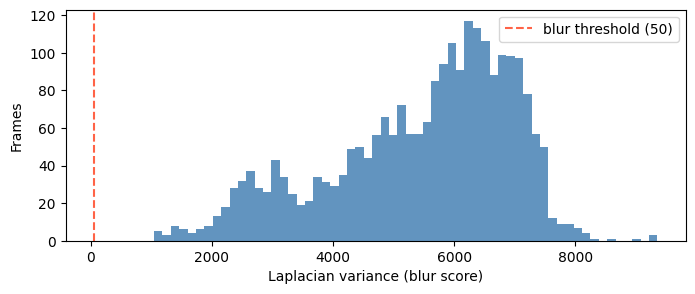

Counter({'accepted': 2388})


In [9]:
# Blur-score distribution; frames left of the threshold line are gate-rejected
blur_scores = [d["blur_score"] for d in frame_scores]
fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(blur_scores, bins=60, color="steelblue", alpha=0.85)
ax.axvline(50.0, color="tomato", linestyle="--", label="blur threshold (50)")
ax.set_xlabel("Laplacian variance (blur score)")
ax.set_ylabel("Frames")
ax.legend()
plt.show()

# Gate outcome counts across the whole video
print(Counter(d["reject_reason"] or "accepted" for d in frame_scores))

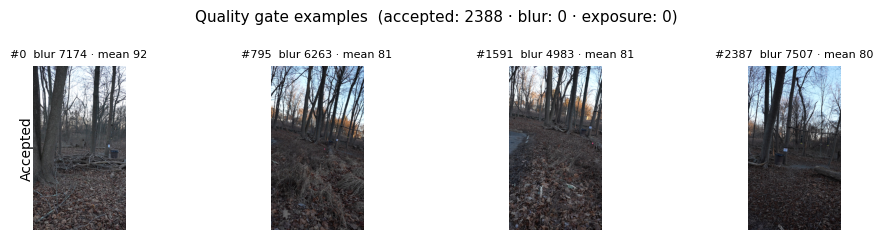

In [10]:
# Example frames per gate outcome — decodes only the displayed frames
plot_quality_examples(VIDEO_PATH, frame_scores)

#### Demo: a stricter gate

This video is sharp and evenly exposed throughout, so the default gate rejects nothing — the grid above only shows accepted frames (a good production outcome). To see the gate in action, re-label the same records with the blur threshold raised to the 10th percentile of this video's blur scores: the softest frames (typically motion-blurred pans) now show up as rejections. No re-decode is needed — the per-frame metrics are already in the records. Exposure rejection works the same way against the mean-intensity bounds.

Demo blur threshold: 3040  (10th percentile of this video's blur scores)


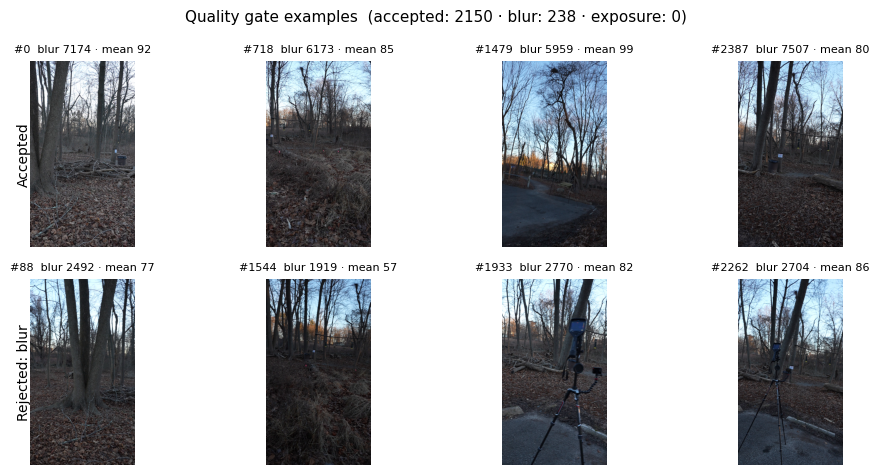

In [11]:
# Re-label records against a stricter demo threshold — flags the softest 10% of frames
demo_threshold = sorted(d["blur_score"] for d in frame_scores)[len(frame_scores) // 10]
demo_scores = [
    {**d, "reject_reason": "blur" if d["blur_score"] < demo_threshold else d["reject_reason"]}
    for d in frame_scores
]
print(f"Demo blur threshold: {demo_threshold:.0f}  (10th percentile of this video's blur scores)")
plot_quality_examples(VIDEO_PATH, demo_scores)

## §4 — Optical Flow Selection

Apply the selection threshold (`score ≥ 0.5`) to the scored frames to pick keyframes. Selected keyframes are extracted to `KEYFRAMES/` as `frame_{idx:06d}.jpg`, preserving the original video frame index.

Extracted 30 OF keyframes → /workspace/outputs/tutorial_cache/2024_02_06/C0043/keyframes


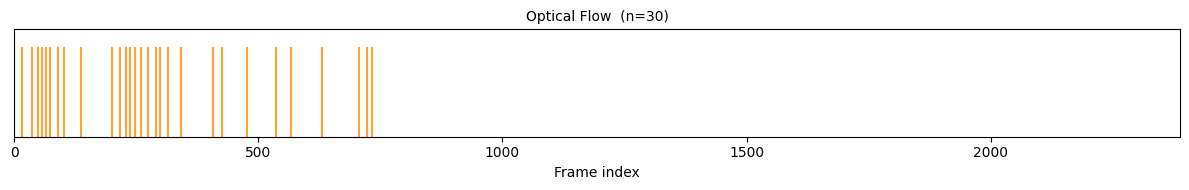

In [12]:
# Derive selected indices from pre-scored frames
of_indices = [d["frame_idx"] for d in frame_scores if d["selected"]][:MAX_FRAMES]

# Extract selected keyframes as frame_{idx:06d}.jpg into the tutorial scratch dir
extract_frames(VIDEO_PATH, of_indices, KEYFRAMES)
print(f"Extracted {len(of_indices)} OF keyframes → {KEYFRAMES}")

# Load OF frames by index from video (rotation applied automatically by the ffmpeg decode)
of_frames = load_frames(VIDEO_PATH, of_indices)
plot_selection(info['total_frames'], of_indices=of_indices)

Grid view of the optical-flow-selected frames. Compare with the FPS grid above — OF tends to capture more visually distinct moments.

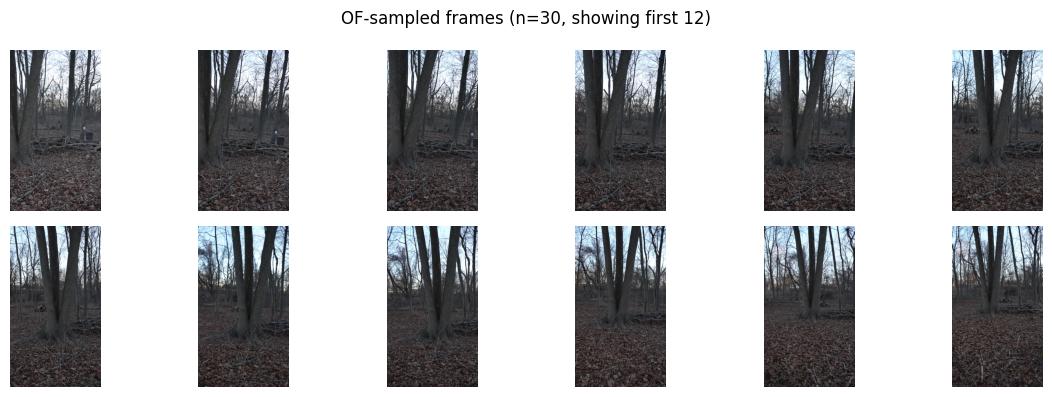

In [13]:
plot_frame_grid(of_frames[:12], title=f"OF-sampled frames (n={len(of_frames)}, showing first 12)")

## §5 — Side-by-Side Comparison

Overlay FPS and OF selections on the same timeline. FPS distributes uniformly in time; OF distributes uniformly in content — the difference is most visible where camera speed varies.

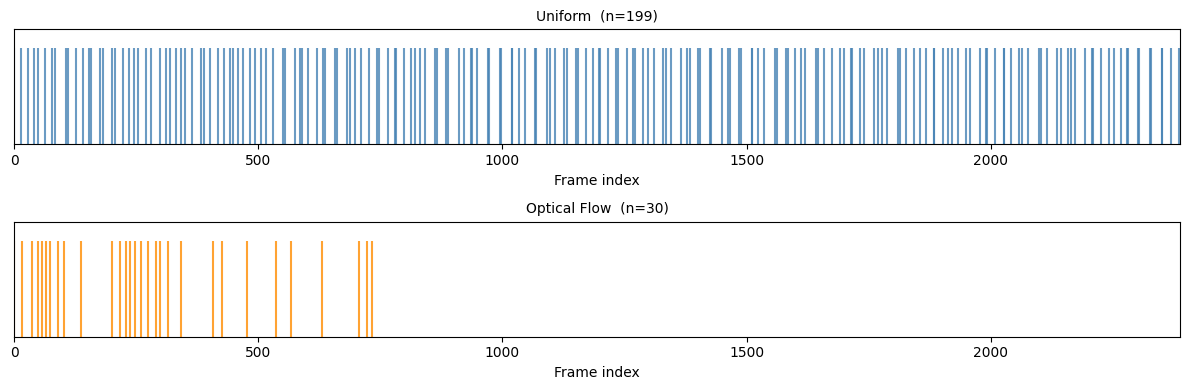

In [14]:
# Overlay FPS and OF selections on the same timeline
plot_selection(info['total_frames'], fps_indices=fps_indices, of_indices=of_indices)

## §6 — Parameter Sensitivity

`min_disparity` controls how much the camera must move before a new frame is accepted. Higher values yield fewer, more distinct frames; lower values give denser coverage at the cost of more redundancy.

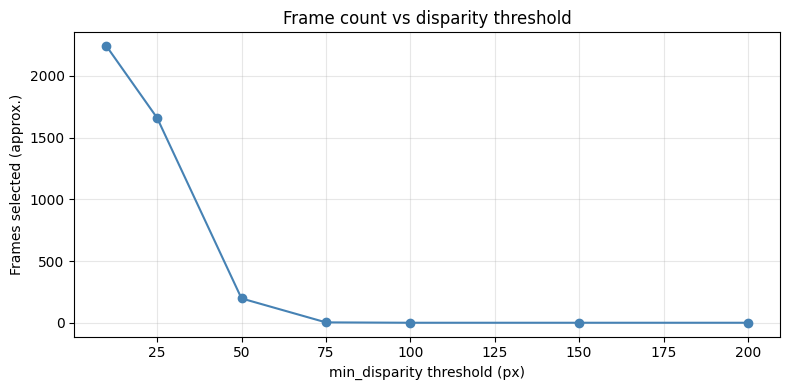

In [15]:
disparity_values = [10.0, 25.0, 50.0, 75.0, 100.0, 150.0, 200.0]
plot_disparity_sensitivity(frame_scores, disparity_values)

## §7 — When to Use Each Method

| Scenario | Recommended | Reason |
|----------|-------------|--------|
| Slow camera pans | Optical flow | Avoids oversampling near-identical frames |
| Handheld walk-through | Either | FPS is simpler; OF is marginally better |
| Fast action / drone | FPS | OF may miss fast transients between keyframes |
| Limited frame budget | Optical flow | Better spatial scene coverage per frame |

**Pipeline knob:** the dashboard pipeline exposes `RunConfig.sampling_method` (`collab_splats/dashboard/config.py`) with values `"balanced"` (uniform sharpest-in-window) and `"optical_flow"`. This notebook's `sample_frames` accepts `method="uniform"` or `"optical_flow"`.